# Mathematical Foundations of Market Microstructure: Explaining 'Hard Samples' in LOB

This notebook serves as an elite analytical and educational guide for the project team. Its goal is to formally define, program, and visualize what constitutes a **"Hard Sample"** within a Limit Order Book (LOB) dataset using the **FI2010 benchmark**.

### Why Global Metrics Lie
When defending this project, we must prove to the professors that overall evaluation metrics (like global Accuracy or F1-Score) can be highly misleading due to the severe dominance of the stationary state (`Flat` regime). Models can look artificially intelligent simply by blindly predicting the majority class, while completely failing at low-latency execution boundaries. These filters isolate these critical moments **mathematically on the training split**, ensuring no **data leakage** occurs.

## 1. Formal Mathematical Definitions and Theoretical Backbone

### Case A: Volume Shock (Iceberg Order Signatures)
In highly liquid electronic markets, large institutional traders often split massive orders into hidden configurations (*Iceberg Orders*) to prevent adverse price impact. This is mathematically visible when the Level 1 Volume Imbalance is exceptionally high, but the localized rolling volatility of the mid-price approaches zero.

Let the mid-price $M_t$ at tick $t$ be defined as:
$$M_t = \frac{P_{ask, 1} + P_{bid, 1}}{2}$$

We calculate the localized rolling standard deviation over a small micro-window $\omega$:
$$\sigma_{M} = \sqrt{\frac{1}{\omega} \sum_{i=-\omega/2}^{\omega/2} (M_{t+i} - \bar{M}_t)^2}$$

The Volume Delta $\Delta V_t$ represents the surface level liquidity skew:
$$\Delta V_t = |V_{bid, 1} - V_{ask, 1}|$$

**A sample is tagged as a Volume Shock Hard Case if:**
$$\sigma_{M} < \epsilon \quad \wedge \quad \Delta V_t > \tau \quad \wedge \quad Y_t \neq \text{Flat}$$
Where $\epsilon$ is a minimal volatility boundary and $\tau$ is an aggressive volume threshold. Shallow models without temporal spatial memory default to the safe `Flat` class, completely missing hidden institutional execution queues.

### Case B: Order Book Divergence (Deep Book Contradictions)
Simple heuristic trading systems (like our `QueueImbalanceBaseline`) look only at Level 1 ($L_1$). However, true algorithmic pressure resides deeper inside the book layers. A structural contradiction occurs when the order book's immediate surface suggests one direction (e.g., strong Bid at $L_1$), but the aggregate pressure of the deep book (Level 5 - $L_5$) indicates the exact opposite. Level $L_5$ acts as the liquidity core providing institutional support zones.

We calculate the directional volume imbalance sign at the surface layer ($L_1$):
$$I_1 = \text{sign}(V_{bid, 1} - V_{ask, 1})$$

And compare it against the directional aggregate volume imbalance deep inside the core profile ($L_5$):
$$I_5 = \text{sign}(V_{bid, 5} - V_{ask, 5})$$

**An execution state is a Deep Contradiction if:**
$$I_1 \neq I_5 \quad \wedge \quad I_1 \neq 0 \quad \wedge \quad I_5 \neq 0 \quad \wedge \quad Y_t \neq \text{Flat}$$
This indicates cross-layer divergence. A shallow Student MLP model, which flattens the input window and destroys geographic grid data, will inevitably fail here. Only `DeepLOB` (via 2D CNN filters) preserves spatial abstraction and filters out this structural noise.

## 2. Academic Literature

1. **Frey, S., & Sandås, P. (2017).** *"The Impact of Iceberg Orders in Limit Order Books."* Quarterly Journal of Finance.
2. **Cont, R., Kukanov, A., & Stoikov, S. (2014).** *"The Price Impact of Order Book Events."* Journal of Financial Econometrics.
3. **Gould, M. D., et al. (2013).** *"Limit order books."* Quantitative Finance.
4. **Zhang, Z., Zohren, S., & Roberts, S. (2019).** *"DeepLOB: Deep convolutional networks for limit order books."* IEEE Transactions on Signal Processing.

In [1]:
# Environment Setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../"))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Workspace anchored to: {PROJECT_ROOT}")

Workspace anchored to: /home/wiktor/CODE/Projects/hft-knowledge-distillation


In [2]:
# Load Training Set
train_path = os.path.join(PROJECT_ROOT, "datasets/FI2010_train.csv")

df = pd.read_csv(train_path)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

label_col = df.columns[-1]
feature_cols = [c for c in df.columns if c != label_col][:40]
features, labels = df[feature_cols].to_numpy(), df[label_col].to_numpy()

if labels.min() == 1:
    labels = labels - 1

print(f"Loaded successfully. Total ticks: {features.shape[0]}")

Loaded successfully. Total ticks: 362400


Asset [1] -> Shocks: 8017 | Divergences: 33255


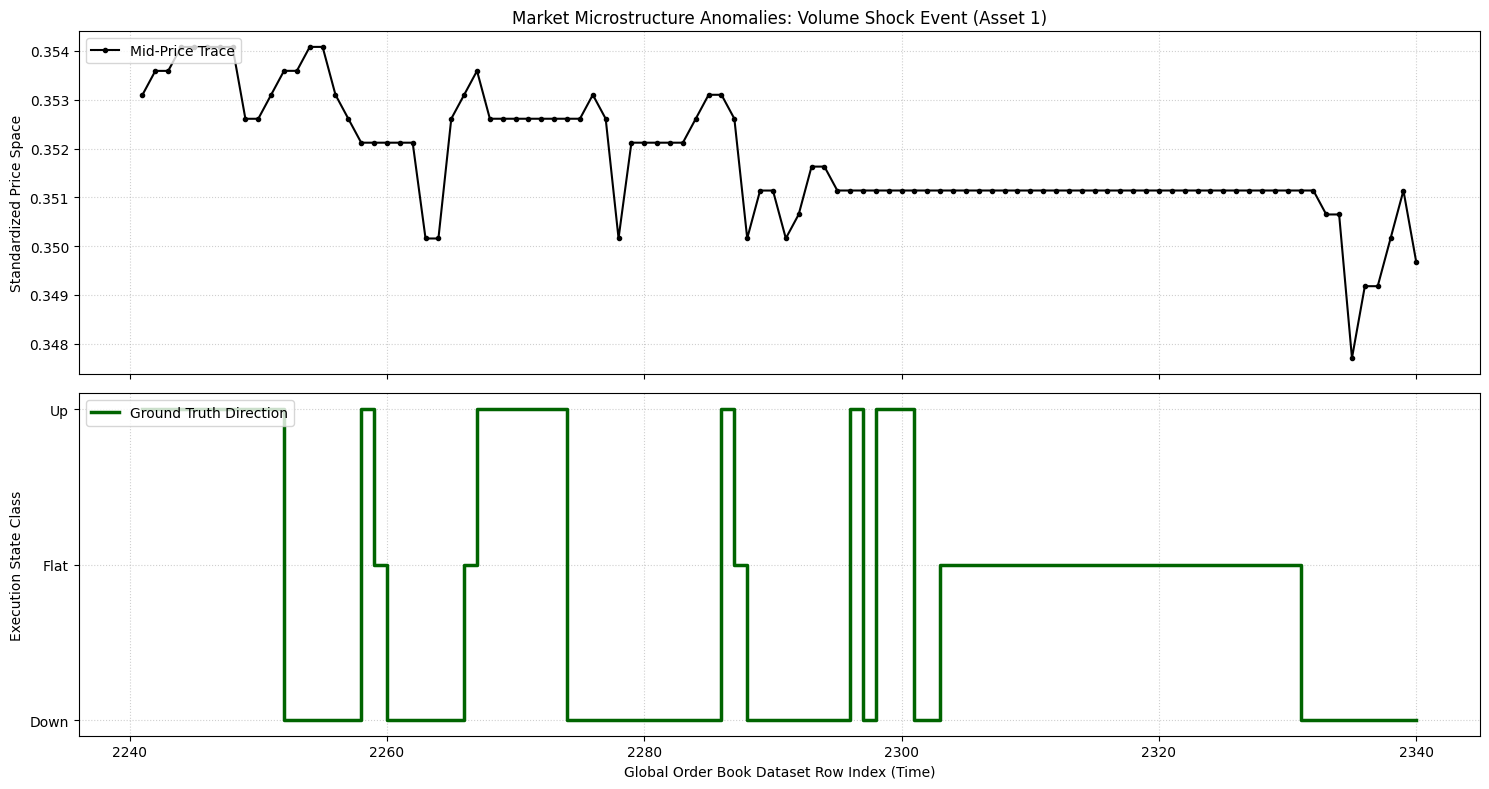

In [3]:
# Profile Filters & Structural Visual Execution
from src.utils.hardness_filters import check_volume_shock, check_depth_divergence

samples_per_asset = len(labels) // 5
target_asset = 1
start = (target_asset - 1) * samples_per_asset
end = target_asset * samples_per_asset

a_features = features[start:end]
a_labels = labels[start:end]

shocks = [i for i in range(50, len(a_labels)-50) if check_volume_shock(a_features, a_labels, i)]
divs = [i for i in range(50, len(a_labels)-50) if check_depth_divergence(a_features, a_labels, i)]
print(f"Asset [{target_asset}] -> Shocks: {len(shocks)} | Divergences: {len(divs)}")

# Render target anomalies directly in the notebook session context
if len(shocks) > 0:
    center_tick = shocks[0]
    L, R = center_tick - 50, center_tick + 50
    time_space = np.arange(L + start, R + start)
    
    fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    
    # Panel 1: Prices
    mid_prices = (a_features[L:R, 0] + a_features[L:R, 2]) / 2.0
    axs[0].plot(time_space, mid_prices, color='black', marker='o', markersize=3, label='Mid-Price Trace')
    axs[0].set_title(f"Market Microstructure Anomalies: Volume Shock Event (Asset {target_asset})")
    axs[0].set_ylabel("Standardized Price Space")
    axs[0].legend(loc='upper left')
    axs[0].grid(True, linestyle=':', alpha=0.6)
    
    # Panel 2: Targets
    axs[1].plot(time_space, a_labels[L:R], color='darkgreen', drawstyle='steps-pre', lw=2.5, label='Ground Truth Direction')
    axs[1].set_yticks([0, 1, 2])
    axs[1].set_yticklabels(['Up', 'Flat', 'Down'])
    axs[1].invert_yaxis()
    axs[1].set_ylabel("Execution State Class")
    axs[1].set_xlabel("Global Order Book Dataset Row Index (Time)")
    axs[1].legend(loc='upper left')
    axs[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
else:
    print("No volume shock indices resolved for this target stock.")